# Customer Segmentation and Retention Strategy Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv('online_retail.csv', encoding='ISO-8859-1')

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
df.shape

(541909, 8)

## 1. Data Understanding

In [7]:
print("Dataset Shape:", df.shape)
print("\nDataset Information:")
df.info()

Dataset Shape: (541909, 8)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [8]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [9]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [10]:
df.describe(include='object')

,InvoiceNo,StockCode,Description,InvoiceDate,Country
count,541909,541909,540455,541909,541909
unique,25900,4070,4223,23260,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2011-10-31 14:41:00,United Kingdom
freq,1114,2313,2369,1114,495478


## 2. Missing Value Analysis

In [11]:
missing_values = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_values

,Missing Values,Missing Percentage
InvoiceNo,0,0.000000
StockCode,0,0.000000
Description,1454,0.268311
Quantity,0,0.000000
InvoiceDate,0,0.000000
UnitPrice,0,0.000000
CustomerID,135080,24.926694
Country,0,0.000000


In [12]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 5268


## 3. Data Cleaning and Feature Engineering

In [15]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df.dtypes


InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

In [16]:
print("First Transaction:", df['InvoiceDate'].min())
print("Last Transaction:", df['InvoiceDate'].max())

First Transaction: 2010-12-01 08:26:00
Last Transaction: 2011-12-09 12:50:00


## 4. Data Cleaning

In [17]:
df_clean = df.copy()

In [18]:
df_clean = df_clean.dropna(subset=['CustomerID'])

print("Shape after removing missing CustomerID:", df_clean.shape)

Shape after removing missing CustomerID: (406829, 8)


In [19]:
df_clean = df_clean.drop_duplicates()

print("Duplicate Rows Remaining:", df_clean.duplicated().sum())
print("Shape after removing duplicates:", df_clean.shape)

Duplicate Rows Remaining: 0
Shape after removing duplicates: (401604, 8)


In [20]:
cancelled_orders = df_clean[
    df_clean['InvoiceNo'].astype(str).str.startswith('C')
]

print("Number of Cancelled Transactions:", cancelled_orders.shape[0])

Number of Cancelled Transactions: 8872


In [21]:
df_clean = df_clean[
    ~df_clean['InvoiceNo'].astype(str).str.startswith('C')
]

print("Shape after removing cancelled transactions:", df_clean.shape)

Shape after removing cancelled transactions: (392732, 8)


In [22]:
df_clean = df_clean[
    (df_clean['Quantity'] > 0) &
    (df_clean['UnitPrice'] > 0)
]

print("Shape after removing invalid transactions:", df_clean.shape)

Shape after removing invalid transactions: (392692, 8)


In [23]:
df_clean.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [25]:
df_clean['TotalAmount'] = (
    df_clean['Quantity'] * df_clean['UnitPrice']
)

In [26]:
df_clean[['Quantity', 'UnitPrice', 'TotalAmount']].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [27]:
print("Final Cleaned Dataset Shape:", df_clean.shape)
print("\nRemaining Missing Values:")
print(df_clean.isnull().sum())

Final Cleaned Dataset Shape: (392692, 9)

Remaining Missing Values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
dtype: int64


## 5. Customer Behaviour Analysis

In [28]:
total_customers = df_clean['CustomerID'].nunique()

total_revenue = df_clean['TotalAmount'].sum()

total_invoices = df_clean['InvoiceNo'].nunique()

print("Total Customers:", total_customers)
print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_invoices)

Total Customers: 4338
Total Revenue: 8887208.89
Total Orders: 18532


In [29]:
average_order_value = total_revenue / total_invoices

print("Average Order Value:", round(average_order_value, 2))

Average Order Value: 479.56


In [30]:
customer_orders = (
    df_clean.groupby('CustomerID')['InvoiceNo']
    .nunique()
)

In [31]:
one_time_customers = (customer_orders == 1).sum()

repeat_customers = (customer_orders > 1).sum()

print("One-Time Customers:", one_time_customers)
print("Repeat Customers:", repeat_customers)

One-Time Customers: 1493
Repeat Customers: 2845


In [32]:
repeat_customer_percentage = (
    repeat_customers / total_customers
) * 100

print(
    "Repeat Customer Percentage:",
    round(repeat_customer_percentage, 2),
    "%"
)

Repeat Customer Percentage: 65.58 %


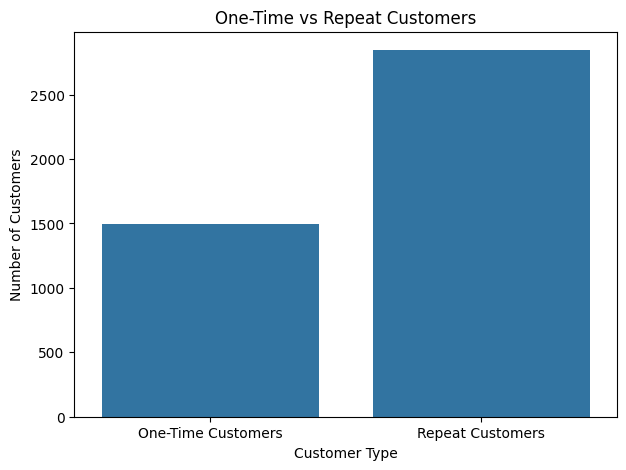

In [33]:
customer_type = pd.Series({
    'One-Time Customers': one_time_customers,
    'Repeat Customers': repeat_customers
})

plt.figure(figsize=(7, 5))

sns.barplot(
    x=customer_type.index,
    y=customer_type.values
)

plt.title('One-Time vs Repeat Customers')
plt.xlabel('Customer Type')
plt.ylabel('Number of Customers')

plt.show()

## 6. Monthly Sales and Customer Activity Analysis

In [34]:
df_clean['Month'] = df_clean['InvoiceDate'].dt.to_period('M')

In [35]:
monthly_revenue = (
    df_clean.groupby('Month')['TotalAmount']
    .sum()
    .reset_index()
)

monthly_revenue

,Month,TotalAmount
0,2010-12,570422.730
1,2011-01,568101.310
2,2011-02,446084.920
3,2011-03,594081.760
4,2011-04,468374.331
5,2011-05,677355.150
6,2011-06,660046.050
7,2011-07,598962.901
8,2011-08,644051.040
9,2011-09,950690.202


In [36]:
monthly_revenue['Month'] = monthly_revenue['Month'].astype(str)

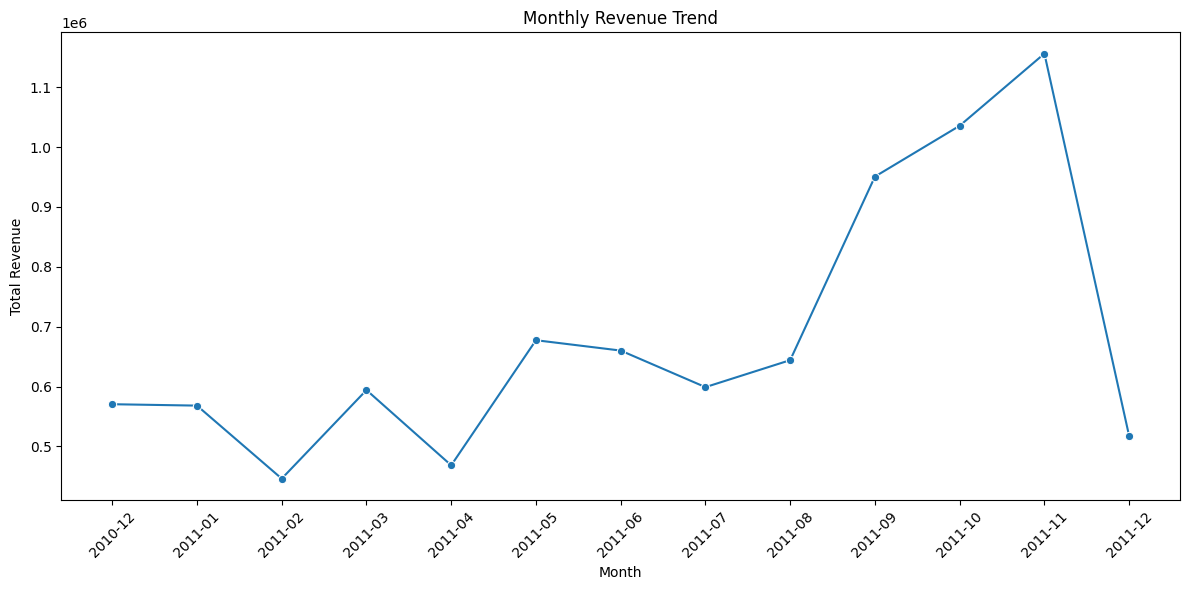

In [37]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_revenue,
    x='Month',
    y='TotalAmount',
    marker='o'
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [38]:
monthly_active_customers = (
    df_clean.groupby('Month')['CustomerID']
    .nunique()
    .reset_index()
)

monthly_active_customers

,Month,CustomerID
0,2010-12,885
1,2011-01,741
2,2011-02,758
3,2011-03,974
4,2011-04,856
5,2011-05,1056
6,2011-06,991
7,2011-07,949
8,2011-08,935
9,2011-09,1266


In [39]:
monthly_active_customers['Month'] = (
    monthly_active_customers['Month'].astype(str)
)

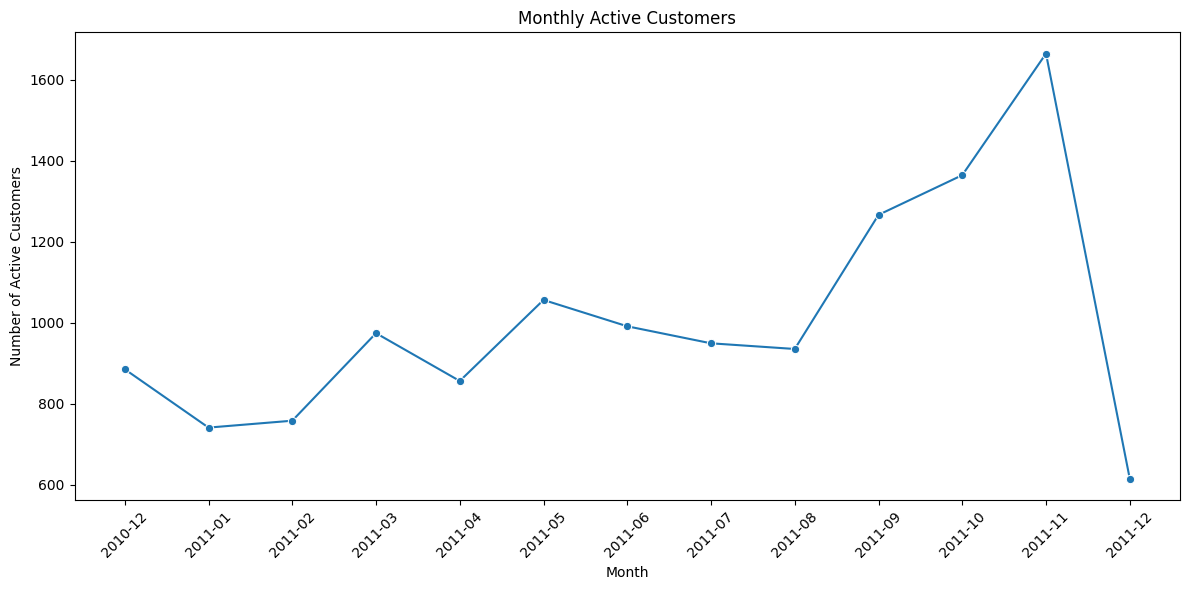

In [40]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_active_customers,
    x='Month',
    y='CustomerID',
    marker='o'
)

plt.title('Monthly Active Customers')
plt.xlabel('Month')
plt.ylabel('Number of Active Customers')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [41]:
monthly_customer_orders = (
    df_clean.groupby(['Month', 'CustomerID'])['InvoiceNo']
    .nunique()
    .reset_index()
)

In [42]:
monthly_repeat_customers = (
    monthly_customer_orders[
        monthly_customer_orders['InvoiceNo'] > 1
    ]
    .groupby('Month')['CustomerID']
    .nunique()
    .reset_index()
)

monthly_repeat_customers

,Month,CustomerID
0,2010-12,263
1,2011-01,149
2,2011-02,149
3,2011-03,201
4,2011-04,168
5,2011-05,279
6,2011-06,219
7,2011-07,227
8,2011-08,196
9,2011-09,271


In [43]:
monthly_repeat_customers['Month'] = (
    monthly_repeat_customers['Month'].astype(str)
)

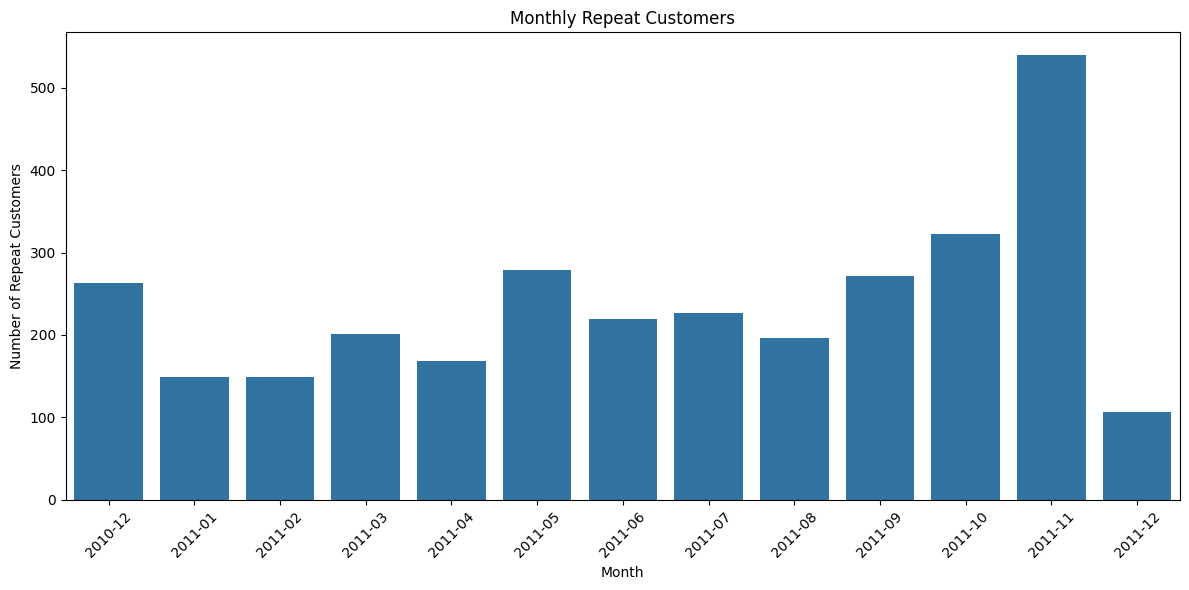

In [44]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=monthly_repeat_customers,
    x='Month',
    y='CustomerID'
)

plt.title('Monthly Repeat Customers')
plt.xlabel('Month')
plt.ylabel('Number of Repeat Customers')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 7. Cohort Retention Analysis

In [45]:
df_clean['InvoiceMonth'] = df_clean['InvoiceDate'].dt.to_period('M')

df_clean['CohortMonth'] = (
    df_clean.groupby('CustomerID')['InvoiceMonth']
    .transform('min')
)

In [46]:
def get_cohort_index(df):
    year_diff = (
        df['InvoiceMonth'].dt.year -
        df['CohortMonth'].dt.year
    )

    month_diff = (
        df['InvoiceMonth'].dt.month -
        df['CohortMonth'].dt.month
    )

    return year_diff * 12 + month_diff + 1


df_clean['CohortIndex'] = get_cohort_index(df_clean)

In [47]:
df_clean[
    ['CustomerID', 'InvoiceMonth', 'CohortMonth', 'CohortIndex']
].head()

,CustomerID,InvoiceMonth,CohortMonth,CohortIndex
0,17850.0,2010-12,2010-12,1
1,17850.0,2010-12,2010-12,1
2,17850.0,2010-12,2010-12,1
3,17850.0,2010-12,2010-12,1
4,17850.0,2010-12,2010-12,1


In [48]:
cohort_data = (
    df_clean.groupby(
        ['CohortMonth', 'CohortIndex']
    )['CustomerID']
    .nunique()
    .reset_index()
)

In [49]:
cohort_counts = cohort_data.pivot(
    index='CohortMonth',
    columns='CohortIndex',
    values='CustomerID'
)

cohort_counts

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12,885.0,324.0,286.0,340.0,321.0,352.0,321.0,309.0,313.0,350.0,331.0,445.0,235.0
2011-01,417.0,92.0,111.0,96.0,134.0,120.0,103.0,101.0,125.0,136.0,152.0,49.0,NaN
2011-02,380.0,71.0,71.0,108.0,103.0,94.0,96.0,106.0,94.0,116.0,26.0,NaN,NaN
2011-03,452.0,68.0,114.0,90.0,101.0,76.0,121.0,104.0,126.0,39.0,NaN,NaN,NaN
2011-04,300.0,64.0,61.0,63.0,59.0,68.0,65.0,78.0,22.0,NaN,NaN,NaN,NaN
2011-05,284.0,54.0,49.0,49.0,59.0,66.0,75.0,27.0,NaN,NaN,NaN,NaN,NaN
2011-06,242.0,42.0,38.0,64.0,56.0,81.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,188.0,34.0,39.0,42.0,51.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,169.0,35.0,42.0,41.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [50]:
cohort_size = cohort_counts.iloc[:, 0]

retention_matrix = cohort_counts.divide(
    cohort_size,
    axis=0
) * 100

retention_matrix

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12,100.0,36.610169,32.316384,38.418079,36.271186,39.774011,36.271186,34.915254,35.367232,39.548023,37.401130,50.282486,26.553672
2011-01,100.0,22.062350,26.618705,23.021583,32.134293,28.776978,24.700240,24.220624,29.976019,32.613909,36.450839,11.750600,NaN
2011-02,100.0,18.684211,18.684211,28.421053,27.105263,24.736842,25.263158,27.894737,24.736842,30.526316,6.842105,NaN,NaN
2011-03,100.0,15.044248,25.221239,19.911504,22.345133,16.814159,26.769912,23.008850,27.876106,8.628319,NaN,NaN,NaN
2011-04,100.0,21.333333,20.333333,21.000000,19.666667,22.666667,21.666667,26.000000,7.333333,NaN,NaN,NaN,NaN
2011-05,100.0,19.014085,17.253521,17.253521,20.774648,23.239437,26.408451,9.507042,NaN,NaN,NaN,NaN,NaN
2011-06,100.0,17.355372,15.702479,26.446281,23.140496,33.471074,9.504132,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,100.0,18.085106,20.744681,22.340426,27.127660,11.170213,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,100.0,20.710059,24.852071,24.260355,12.426036,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


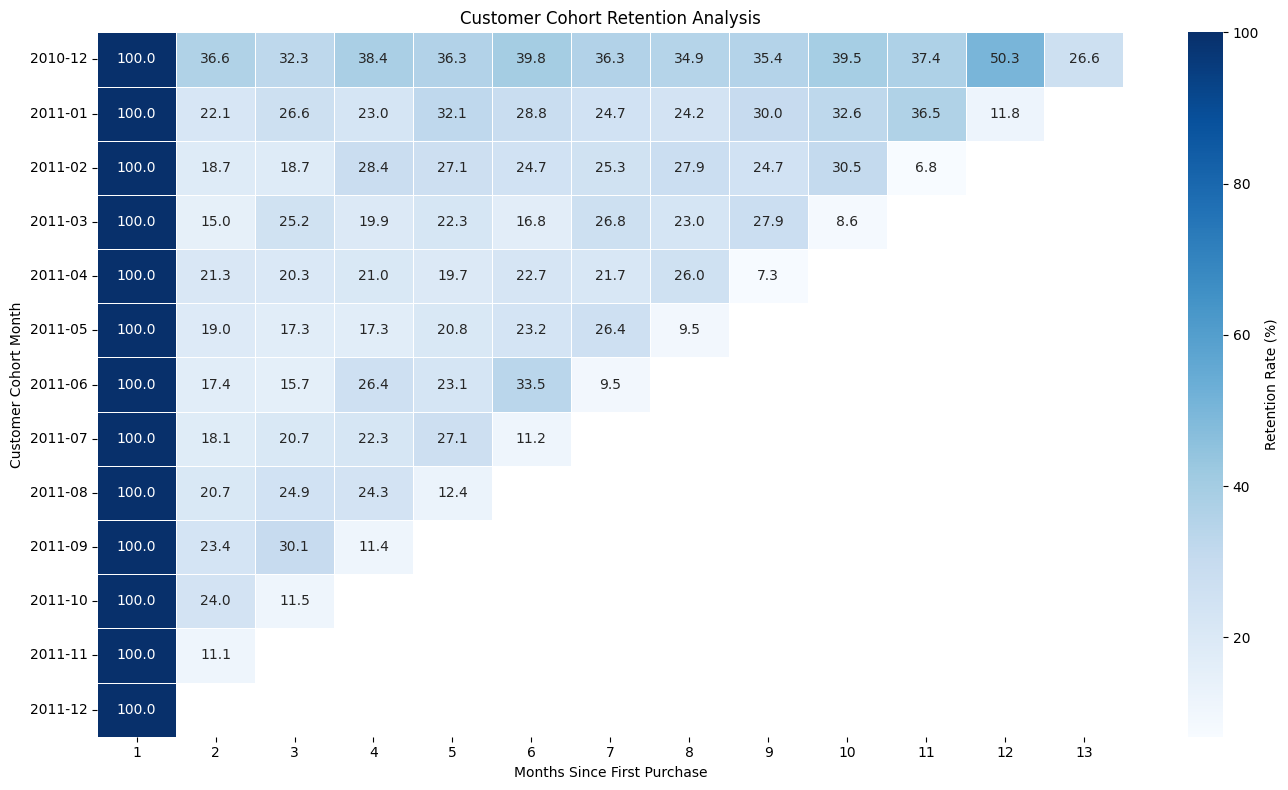

In [51]:
plt.figure(figsize=(14, 8))

sns.heatmap(
    retention_matrix,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    linewidths=0.5,
    cbar_kws={'label': 'Retention Rate (%)'}
)

plt.title('Customer Cohort Retention Analysis')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Customer Cohort Month')

plt.tight_layout()
plt.show()

## 8. RFM Customer Segmentation

In [52]:
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

print("Reference Date:", reference_date)

Reference Date: 2011-12-10 12:50:00


In [53]:
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
}).reset_index()

In [54]:
rfm.columns = [
    'CustomerID',
    'Recency',
    'Frequency',
    'Monetary'
]

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [55]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


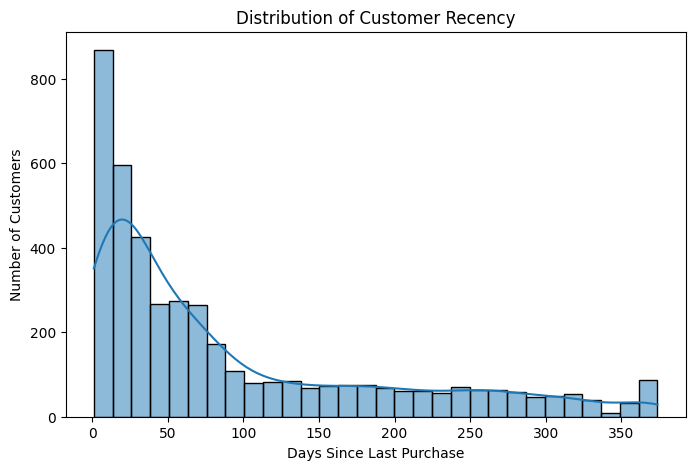

In [56]:
plt.figure(figsize=(8, 5))
sns.histplot(rfm['Recency'], bins=30, kde=True)

plt.title('Distribution of Customer Recency')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Number of Customers')

plt.show()

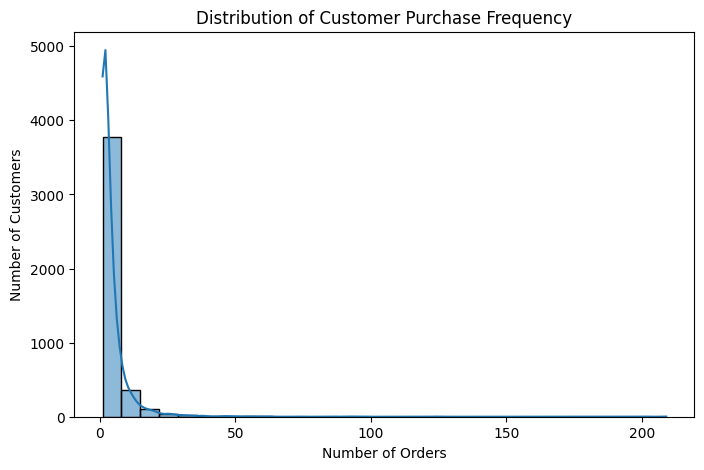

In [57]:
plt.figure(figsize=(8, 5))
sns.histplot(rfm['Frequency'], bins=30, kde=True)

plt.title('Distribution of Customer Purchase Frequency')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')

plt.show()

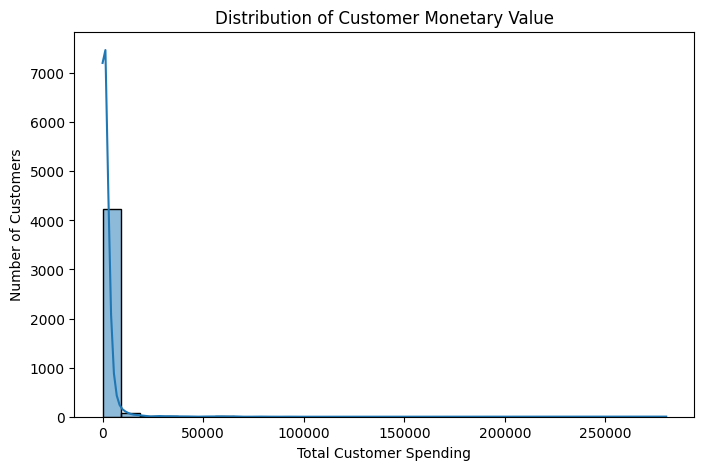

In [58]:
plt.figure(figsize=(8, 5))
sns.histplot(rfm['Monetary'], bins=30, kde=True)

plt.title('Distribution of Customer Monetary Value')
plt.xlabel('Total Customer Spending')
plt.ylabel('Number of Customers')

plt.show()

In [59]:
rfm[['Recency', 'Frequency', 'Monetary']].skew()

Recency       1.246048
Frequency    12.067031
Monetary     19.339368
dtype: float64

In [60]:
rfm_transformed = rfm.copy()

In [61]:
rfm_transformed['Frequency'] = np.log1p(
    rfm_transformed['Frequency']
)

rfm_transformed['Monetary'] = np.log1p(
    rfm_transformed['Monetary']
)

In [62]:
rfm_transformed.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,0.693147,11.253955
1,12347.0,2,2.079442,8.368925
2,12348.0,75,1.609438,7.494564
3,12349.0,19,0.693147,7.472245
4,12350.0,310,0.693147,5.815324


In [63]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm_transformed[
        ['Recency', 'Frequency', 'Monetary']
    ]
)

In [64]:
rfm_scaled[:5]

array([[ 2.33457414, -0.95521426,  3.7077163 ],
       [-0.90534032,  1.07442519,  1.41490344],
       [-0.17535959,  0.38630445,  0.72002428],
       [-0.73534481, -0.95521426,  0.70228691],
       [ 2.17457836, -0.95521426, -0.61451388]])

In [65]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(rfm_scaled)
    
    inertia.append(kmeans.inertia_)

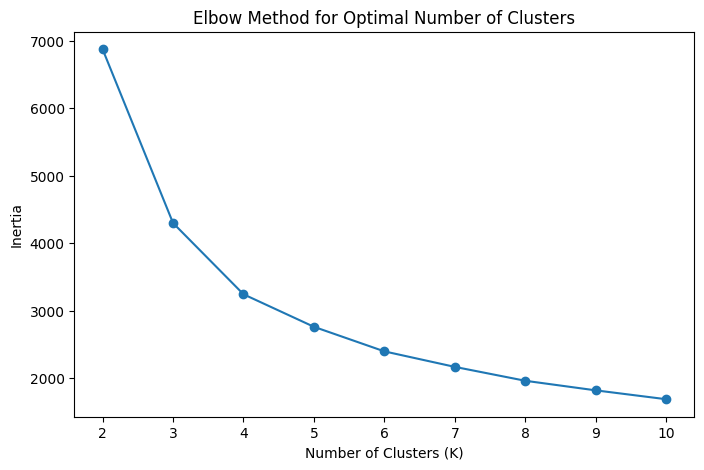

In [66]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker='o'
)

plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')

plt.xticks(range(2, 11))

plt.show()

## 9. Customer Segmentation Using K-Means Clustering

In [67]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,0
1,12347.0,2,7,4310.00,0
2,12348.0,75,4,1797.24,0
3,12349.0,19,1,1757.55,2
4,12350.0,310,1,334.40,1


In [68]:
rfm['Cluster'].value_counts().sort_index()

Cluster
0    1320
1     981
2    2037
Name: count, dtype: int64

In [69]:
cluster_summary = (
    rfm.groupby('Cluster')[
        ['Recency', 'Frequency', 'Monetary']
    ]
    .mean()
    .round(2)
)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,30.10,9.84,5492.04
1,255.11,1.39,397.17
2,54.70,2.05,612.71


In [70]:
cluster_sizes = (
    rfm.groupby('Cluster')
    .size()
    .reset_index(name='Number of Customers')
)

cluster_sizes

,Cluster,Number of Customers
0,0,1320
1,1,981
2,2,2037


In [71]:
cluster_names = {
    0: 'High-Value Loyal Customers',
    1: 'Inactive / At-Risk Customers',
    2: 'Regular Low-Value Customers'
}

rfm['CustomerSegment'] = rfm['Cluster'].map(cluster_names)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,CustomerSegment
0,12346.0,326,1,77183.60,0,High-Value Loyal Customers
1,12347.0,2,7,4310.00,0,High-Value Loyal Customers
2,12348.0,75,4,1797.24,0,High-Value Loyal Customers
3,12349.0,19,1,1757.55,2,Regular Low-Value Customers
4,12350.0,310,1,334.40,1,Inactive / At-Risk Customers


In [72]:
segment_counts = (
    rfm['CustomerSegment']
    .value_counts()
    .reset_index()
)

segment_counts.columns = [
    'Customer Segment',
    'Number of Customers'
]

segment_counts

,Customer Segment,Number of Customers
0,Regular Low-Value Customers,2037
1,High-Value Loyal Customers,1320
2,Inactive / At-Risk Customers,981


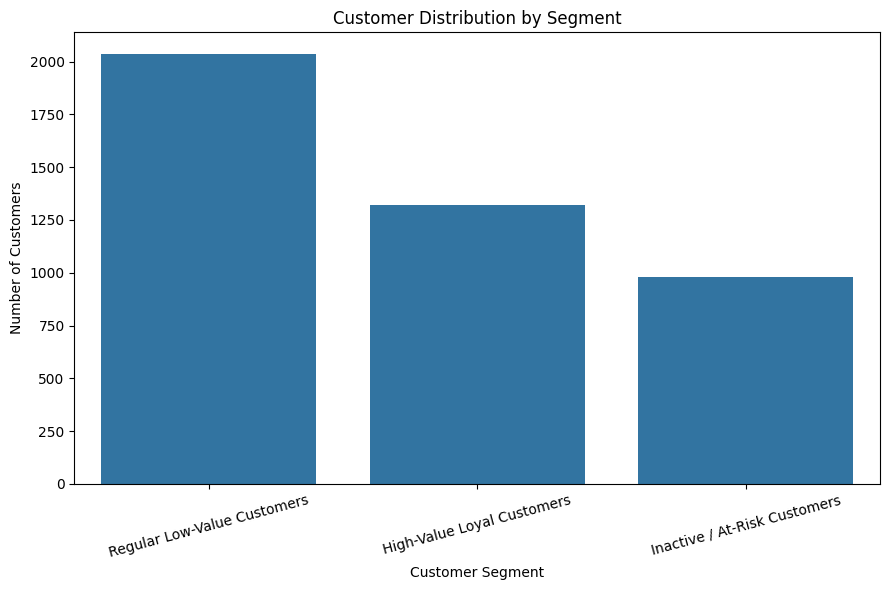

In [73]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=segment_counts,
    x='Customer Segment',
    y='Number of Customers'
)

plt.title('Customer Distribution by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [74]:
segment_summary = (
    rfm.groupby('CustomerSegment')[
        ['Recency', 'Frequency', 'Monetary']
    ]
    .mean()
    .round(2)
)

segment_summary

,Recency,Frequency,Monetary
CustomerSegment,,,
High-Value Loyal Customers,30.10,9.84,5492.04
Inactive / At-Risk Customers,255.11,1.39,397.17
Regular Low-Value Customers,54.70,2.05,612.71


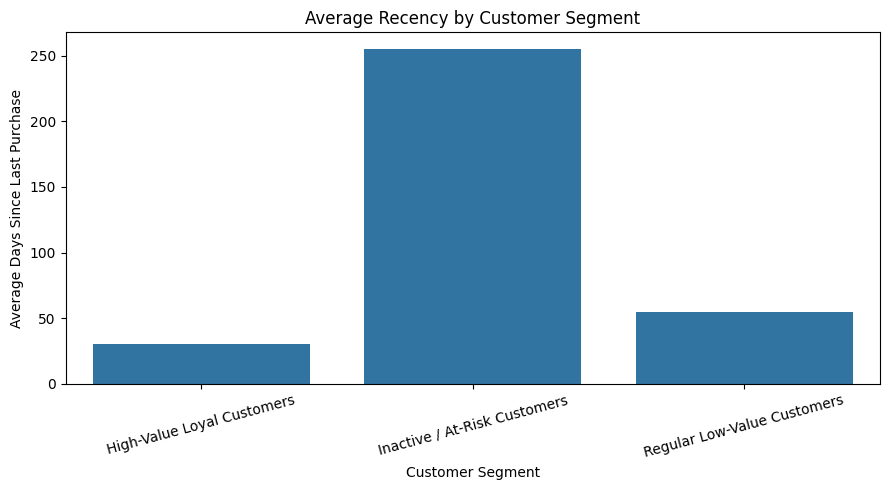

In [75]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=segment_summary.reset_index(),
    x='CustomerSegment',
    y='Recency'
)

plt.title('Average Recency by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Days Since Last Purchase')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

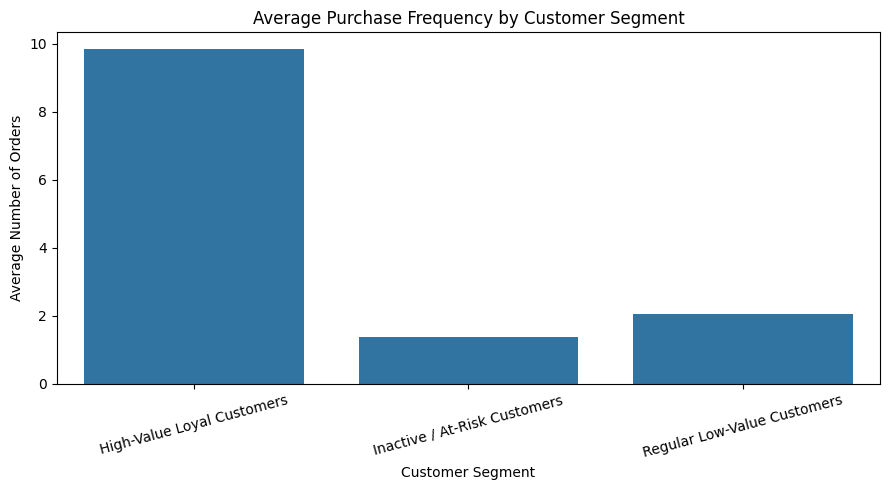

In [76]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=segment_summary.reset_index(),
    x='CustomerSegment',
    y='Frequency'
)

plt.title('Average Purchase Frequency by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Number of Orders')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

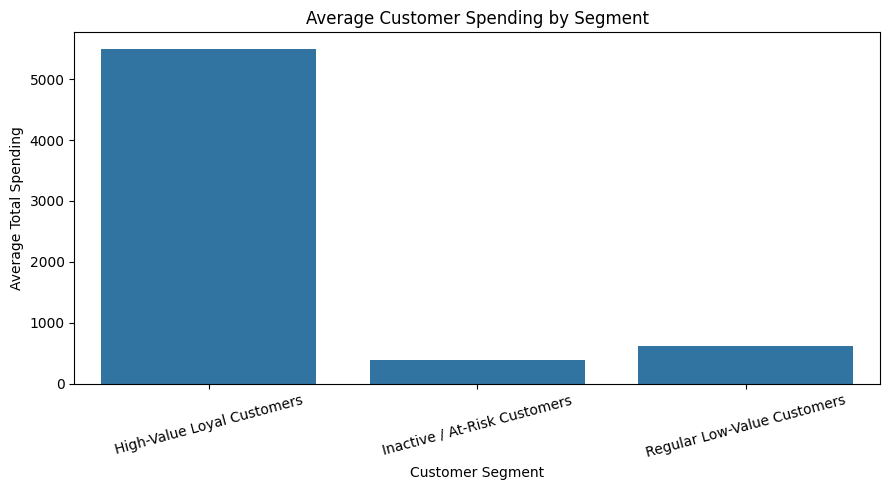

In [77]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=segment_summary.reset_index(),
    x='CustomerSegment',
    y='Monetary'
)

plt.title('Average Customer Spending by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Total Spending')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [78]:
segment_business_summary = (
    rfm.groupby('CustomerSegment')
    .agg(
        Number_of_Customers=('CustomerID', 'count'),
        Average_Recency=('Recency', 'mean'),
        Average_Frequency=('Frequency', 'mean'),
        Average_Monetary_Value=('Monetary', 'mean'),
        Total_Revenue=('Monetary', 'sum')
    )
    .round(2)
)

segment_business_summary

,Number_of_Customers,Average_Recency,Average_Frequency,Average_Monetary_Value,Total_Revenue
CustomerSegment,,,,,
High-Value Loyal Customers,1320,30.10,9.84,5492.04,7249492.37
Inactive / At-Risk Customers,981,255.11,1.39,397.17,389626.80
Regular Low-Value Customers,2037,54.70,2.05,612.71,1248089.72


## 10. Customer Retention Strategy

In [79]:
retention_strategy = pd.DataFrame({
    'Customer Segment': [
        'High-Value Loyal Customers',
        'Regular Low-Value Customers',
        'Inactive / At-Risk Customers'
    ],
    
    'Recommended Strategy': [
        'Maintain loyalty through personalized rewards and exclusive benefits.',
        'Encourage repeat purchases through targeted promotions and cross-selling.',
        'Use win-back campaigns and personalized offers to reactivate customers.'
    ]
})

retention_strategy

,Customer Segment,Recommended Strategy
0,High-Value Loyal Customers,Maintain loyalty through personalized rewards ...
1,Regular Low-Value Customers,Encourage repeat purchases through targeted pr...
2,Inactive / At-Risk Customers,Use win-back campaigns and personalized offers...


In [80]:
segment_revenue = (
    rfm.groupby('CustomerSegment')['Monetary']
    .sum()
    .reset_index()
)

segment_revenue.columns = [
    'Customer Segment',
    'Total Revenue'
]

segment_revenue['Revenue Contribution (%)'] = (
    segment_revenue['Total Revenue'] /
    segment_revenue['Total Revenue'].sum() * 100
).round(2)

segment_revenue

,Customer Segment,Total Revenue,Revenue Contribution (%)
0,High-Value Loyal Customers,7249492.370,81.57
1,Inactive / At-Risk Customers,389626.801,4.38
2,Regular Low-Value Customers,1248089.723,14.04


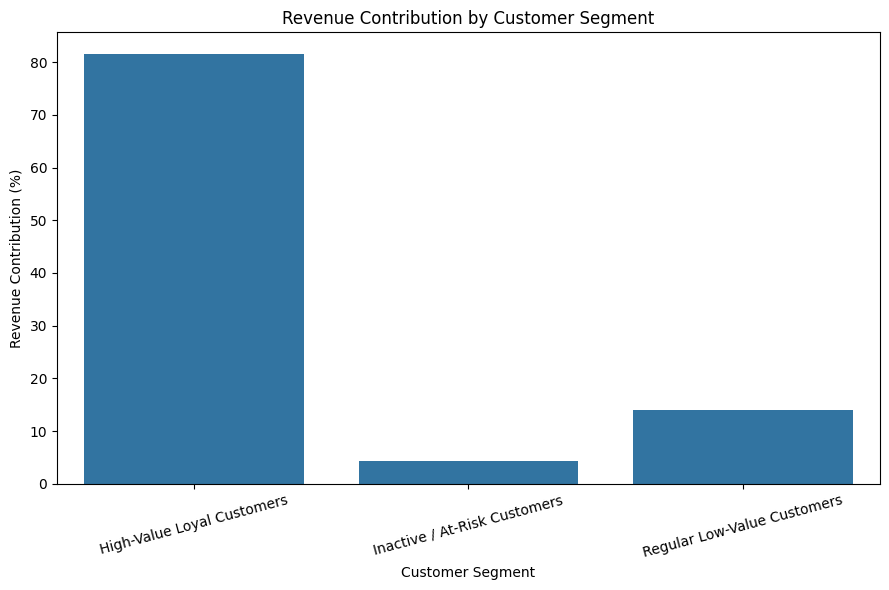

In [81]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=segment_revenue,
    x='Customer Segment',
    y='Revenue Contribution (%)'
)

plt.title('Revenue Contribution by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Revenue Contribution (%)')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [82]:
at_risk_customers = rfm[
    rfm['CustomerSegment'] ==
    'Inactive / At-Risk Customers'
]

at_risk_customers.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,CustomerSegment
4,12350.0,310,1,334.4,1,Inactive / At-Risk Customers
6,12353.0,204,1,89.0,1,Inactive / At-Risk Customers
7,12354.0,232,1,1079.4,1,Inactive / At-Risk Customers
8,12355.0,214,1,459.4,1,Inactive / At-Risk Customers
14,12361.0,287,1,189.9,1,Inactive / At-Risk Customers


In [83]:
print(
    "Number of At-Risk Customers:",
    at_risk_customers.shape[0]
)

Number of At-Risk Customers: 981


### Customer Segment Relationship Analysis

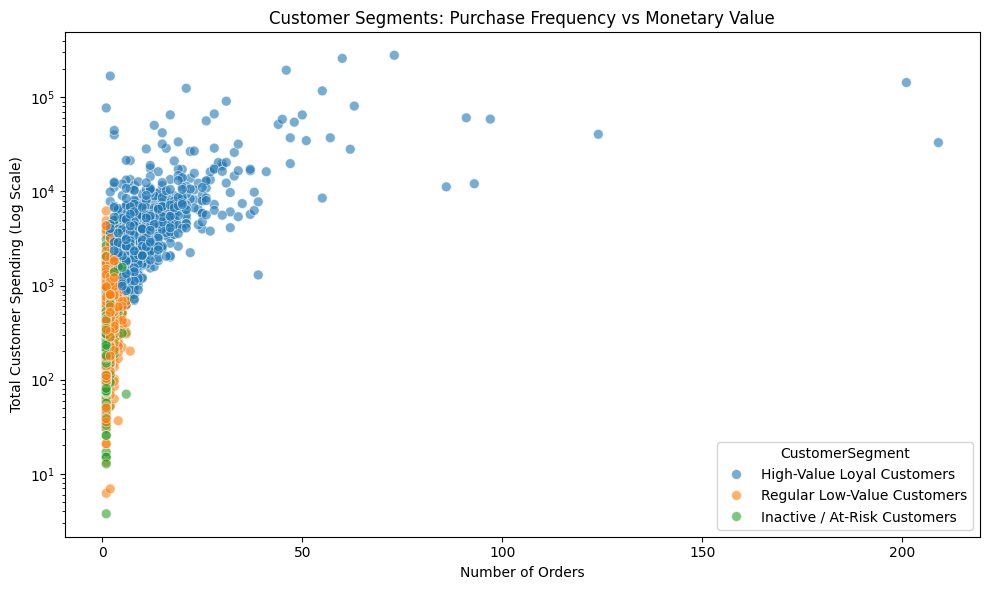

In [84]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='CustomerSegment',
    alpha=0.6,
    s=50
)

plt.yscale('log')

plt.title('Customer Segments: Purchase Frequency vs Monetary Value')
plt.xlabel('Number of Orders')
plt.ylabel('Total Customer Spending (Log Scale)')

plt.tight_layout()
plt.show()

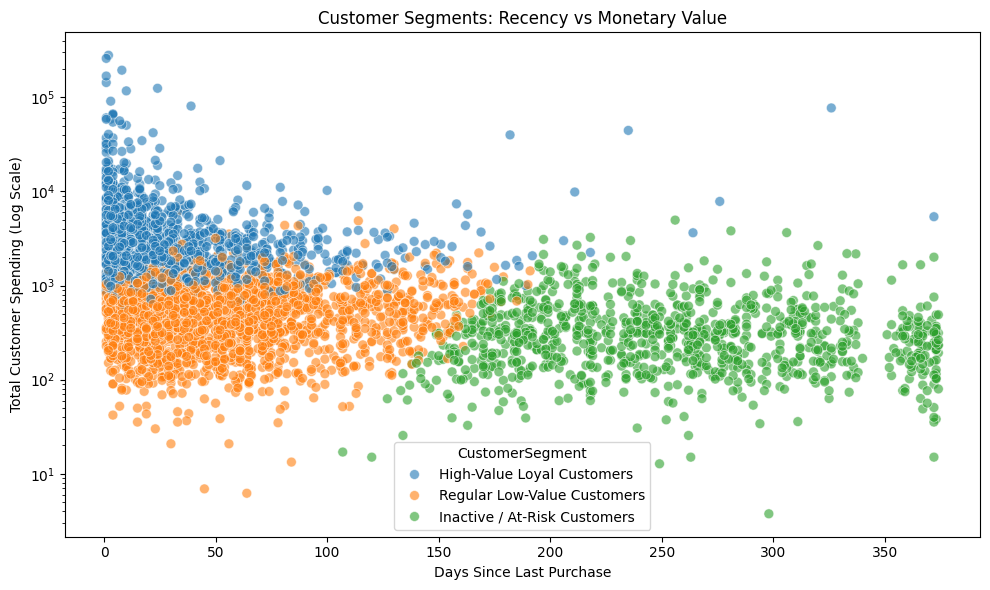

In [85]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='CustomerSegment',
    alpha=0.6,
    s=50
)

plt.yscale('log')

plt.title('Customer Segments: Recency vs Monetary Value')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Total Customer Spending (Log Scale)')

plt.tight_layout()
plt.show()

In [86]:
segment_profile = (
    rfm.groupby('CustomerSegment')[
        ['Recency', 'Frequency', 'Monetary']
    ]
    .mean()
)

In [87]:
segment_profile_normalized = (
    (segment_profile - segment_profile.min()) /
    (segment_profile.max() - segment_profile.min())
)

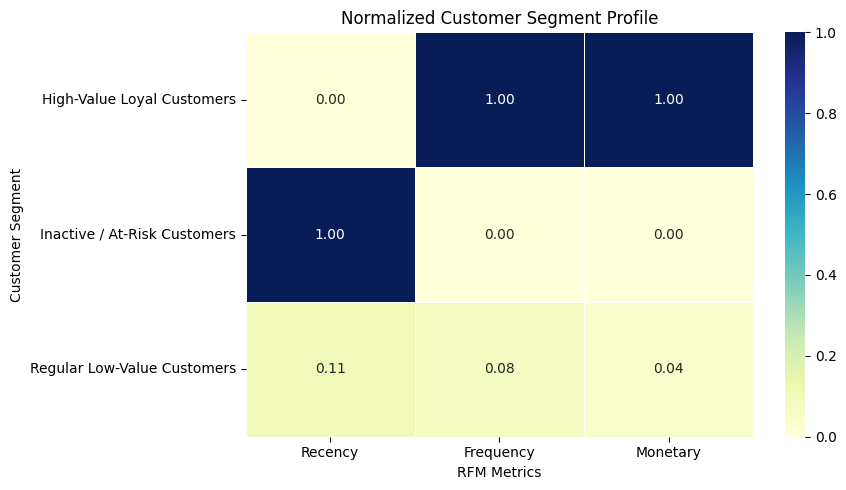

In [88]:
plt.figure(figsize=(9, 5))

sns.heatmap(
    segment_profile_normalized,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',
    linewidths=0.5
)

plt.title('Normalized Customer Segment Profile')
plt.xlabel('RFM Metrics')
plt.ylabel('Customer Segment')

plt.tight_layout()
plt.show()

## 11. Key Findings

- The final cleaned dataset contained 392,692 valid transaction records from 4,338 unique customers, generating total revenue of approximately 8.89 million across 18,532 orders.

- The average order value was approximately 479.56, providing an overall measure of customer purchasing value.

- Approximately 65.58% of customers were repeat customers, while 34.42% were one-time customers. This indicates that repeat purchasing behavior represents an important component of the business.

- RFM analysis and K-Means clustering identified three distinct customer segments with significantly different purchasing behavior.

- High-Value Loyal Customers represented 1,320 customers, approximately 30% of the total customer base, but generated approximately 81.57% of total revenue. This demonstrates a strong concentration of revenue among a relatively small group of highly valuable customers.

- High-Value Loyal Customers had the lowest average recency (30.10 days), the highest average purchase frequency (9.84 orders), and the highest average monetary value (5,492.04), making them the most valuable customer segment.

- Inactive / At-Risk Customers had the highest average recency of 255.11 days, along with low purchase frequency (1.39 orders) and low average monetary value (397.17). These customers represent the primary target group for reactivation and retention campaigns.

- Regular Low-Value Customers formed the largest customer segment with 2,037 customers. They generated approximately 14.04% of total revenue, indicating an opportunity to increase their purchase frequency and spending through targeted engagement strategies.

- Cohort retention analysis provided a month-by-month view of customer retention, highlighting how customer engagement changes after the first purchase and supporting the identification of potential retention opportunities.

- Overall, the analysis shows that customer value is highly unevenly distributed, making customer segmentation and targeted retention strategies more effective than applying the same marketing approach to the entire customer base.

## 12. Business Recommendations

1. **Protect High-Value Loyal Customers**  
   Since approximately 30% of customers contribute 81.57% of total revenue, the business should prioritize retaining these customers through personalized rewards, exclusive benefits, and loyalty programs.

2. **Reactivate Inactive / At-Risk Customers**  
   Customers in this segment have an average recency of 255.11 days and low purchase frequency. Targeted win-back campaigns, personalized offers, and reminder communications could help encourage them to return.

3. **Increase the Value of Regular Low-Value Customers**  
   As the largest customer segment, these customers represent an opportunity for growth. Product recommendations, cross-selling, and targeted promotions could increase their purchase frequency and spending.

4. **Use Cohort Retention Analysis for Continuous Monitoring**  
   The business should regularly monitor retention patterns across customer cohorts to identify periods where customer engagement declines and take timely corrective action.

5. **Adopt Segment-Specific Marketing Strategies**  
   Instead of applying the same marketing strategy to all customers, campaigns should be tailored according to customer recency, purchase frequency, and spending behavior to improve marketing efficiency and customer retention.

## 13. Conclusion

This project analyzed customer purchasing behavior using transaction-level data to understand customer value, purchasing patterns, and retention behavior.

RFM analysis and K-Means clustering identified three distinct customer segments with significantly different characteristics. The analysis showed that High-Value Loyal Customers, despite representing a smaller proportion of the customer base, generated the majority of total revenue. In contrast, Inactive / At-Risk Customers require reactivation efforts, while Regular Low-Value Customers present an opportunity for increased engagement and revenue growth.

The combination of cohort retention analysis and customer segmentation provides actionable insights for targeted marketing and customer retention strategies. Overall, the analysis demonstrates how data-driven customer segmentation can help businesses prioritize valuable customers, improve retention, and allocate marketing resources more effectively.